# Computer Exercise 14.7 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: §14.7 Incremental SGD / Mini-batch Online Learning — 확률적 경사하강과 학습률 스케줄
> **풀이 일자**: 2026-07-07 (자동 생성)
> **언어**: 본문 한국어 / 그래프 라벨 영문

**주제**: 선형회귀를 **확률적 경사하강(SGD)** 으로 온라인 학습하고, **학습률 스케줄** (상수 vs 감쇠 $\eta_t=\eta_0/t^{\alpha}$)이 수렴에 미치는 영향과 **Robbins-Monro 조건** $\sum\eta_t=\infty,\ \sum\eta_t^2<\infty$ 의 의미를 확인한다.


## 1. 문제 (원문)

> **1.** Implement **stochastic gradient descent (SGD)** for a linear regression model that processes one sample at a time. Study the effect of the **step-size (learning-rate) schedule** $\eta_t$ on convergence: compare a *constant* rate with *decaying* rates $\eta_t=\eta_0/t^{\alpha}$ for several $\alpha$. Relate the observed behaviour to the **Robbins–Monro conditions** $\sum_t \eta_t=\infty$ and $\sum_t \eta_t^2<\infty$. Plot the parameter error versus the number of samples on a log–log scale and identify which schedules converge to the true coefficients.

### 한국어 풀이용 정리
- 참계수 $\beta^\star$ 가 고정된 **정상(stationary)** 스트림 $y_t=\phi_t^\top\beta^\star+\varepsilon_t$ 를 만든다.
- 매 샘플마다 **1-샘플 그래디언트**로 $\hat\beta$ 를 한 번 갱신하는 SGD 를 구현한다.
- 상수 학습률과 감쇠 학습률 $\eta_0/t^\alpha$ ($\alpha\in\{0,\,0.5,\,0.7,\,1.0\}$)를 비교한다.
- 계수오차 $\|\hat\beta_t-\beta^\star\|$ 를 로그-로그로 그려 어떤 스케줄이 참값에 **수렴**하는지 본다.
- Robbins-Monro 두 조건이 각각 *왜* 필요한지 그래프로 해석한다.

## 2. 수학적 배경

### 2.1 SGD 갱신식
제곱오차 $\ell_t(\beta)=\tfrac12(y_t-\phi_t^\top\beta)^2$ 의 그래디언트는 $\nabla\ell_t=-(y_t-\phi_t^\top\beta)\,\phi_t=-e_t\,\phi_t$ 이므로 온라인 갱신은
$$\hat\beta_t=\hat\beta_{t-1}+\eta_t\,e_t\,\phi_t,\qquad e_t=y_t-\phi_t^\top\hat\beta_{t-1}.$$
배치 정규방정식(§14.6 의 RLS)이 $\mathcal O(p^2)$ 갱신인 것과 달리 SGD 는 **샘플당 $\mathcal O(p)$** 로 더 싸지만, 1-샘플 그래디언트가 잡음을 담아 갱신이 요동친다.

### 2.2 Robbins-Monro 조건
확률근사 이론에 따르면 감쇠 학습률이 다음 두 조건을 만족하면 $\hat\beta_t\to\beta^\star$ (a.s.):
$$\boxed{\;\sum_{t}\eta_t=\infty\quad(\text{충분히 멀리 이동})\;,\qquad \sum_{t}\eta_t^2<\infty\quad(\text{잡음 소멸})\;}$$
$\eta_t=\eta_0/t^\alpha$ 는 $\tfrac12<\alpha\le1$ 일 때 두 조건을 **동시에** 만족한다. $\alpha=0$(상수)은 첫 조건만, $\alpha>1$ 은 둘째만 만족 → 수렴 실패 또는 조기 정지.

### 2.3 상수 학습률의 잔차 분산
상수 $\eta$ 는 $\sum\eta_t^2=\infty$ 이므로 참값에 **수렴하지 못하고**, 계수는 $\beta^\star$ 주변에서 분산 $\propto\eta$ 인 정상분포로 요동한다(‘steady-state jitter’). 이것이 뒤(Problem 3)에서 **비정상 추적**에는 오히려 장점이 된다.

## 3. 풀이 흐름

1. **정상 스트림 생성**: $\phi_t=[1,x_t,x_t^2]^\top$, 참계수 $\beta^\star=(2,-1,0.5)$, 잡음 $\varepsilon_t\sim\mathcal N(0,\sigma^2)$.
2. **SGD 함수**: 스케줄 $\eta_t$ 를 인자로 받아 계수궤적 $\hat\beta_{0:T}$ 와 오차궤적을 반환.
3. **스케줄 목록**: 상수 $\eta=0.05$, 그리고 $\eta_t=\eta_0/t^\alpha$ 의 $\alpha\in\{0.5,0.7,1.0\}$.
4. **오차 측정**: $\|\hat\beta_t-\beta^\star\|_2$ 를 매 스텝 기록.
5. **표**: 각 스케줄의 최종오차, $\sum\eta_t$·$\sum\eta_t^2$(수렴 여부 진단).
6. **시각화**: (좌) 오차 로그-로그 곡선, (우) 학습률 스케줄 자체.
7. **해석**: 어떤 $\alpha$ 가 Robbins-Monro 를 만족해 실제로 수렴했는지 대조.

In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt

rng = np.random.default_rng(20260707)
T = 20000
sigma = 0.30
beta_star = np.array([2.0, -1.0, 0.5])
p = beta_star.size

x = rng.uniform(-1, 1, T)
Phi = np.stack([np.ones(T), x, x**2], axis=1)          # (T,3) design rows
y = Phi @ beta_star + rng.normal(0, sigma, T)

def sgd(eta_fn, Phi, y, beta0=None):
    """온라인 SGD. eta_fn(t)->step at 1-based step t. returns (traj, err, etas)."""
    T, p = Phi.shape
    beta = np.zeros(p) if beta0 is None else beta0.astype(float).copy()
    traj = np.empty((T, p)); err = np.empty(T); etas = np.empty(T)
    for t in range(T):
        phi = Phi[t]
        e = y[t] - phi @ beta
        eta = eta_fn(t + 1)
        beta = beta + eta * e * phi
        traj[t] = beta; err[t] = np.linalg.norm(beta - beta_star); etas[t] = eta
    return traj, err, etas

schedules = {
    'const 0.05'      : lambda t: 0.05,
    'eta0/t^0.5'      : lambda t: 0.5 / t**0.5,
    'eta0/t^0.7'      : lambda t: 0.5 / t**0.7,
    'eta0/t^1.0'      : lambda t: 0.5 / t**1.0,
}

results = {}
rows = []
for name, fn in schedules.items():
    traj, err, etas = sgd(fn, Phi, y)
    results[name] = (traj, err, etas)
    sum_eta = etas.sum(); sum_eta2 = (etas**2).sum()
    final_err = np.mean(err[-200:])   # smoothed tail error
    rows.append({'schedule': name, 'sum_eta': sum_eta, 'sum_eta2': sum_eta2,
                 'tail_err': final_err})
df = pd.DataFrame(rows).set_index('schedule')
print('T =', T, ' true beta =', beta_star)

T = 20000  true beta = [ 2.  -1.   0.5]


In [3]:
pd.set_option('display.float_format', lambda v: f'{v:.4g}')
df

,sum_eta,sum_eta2,tail_err
schedule,,,
const 0.05,1000,50,0.1109
eta0/t^0.5,140.7,2.62,0.0224
eta0/t^0.7,31.13,0.7645,0.09962
eta0/t^1.0,5.24,0.4112,0.7323


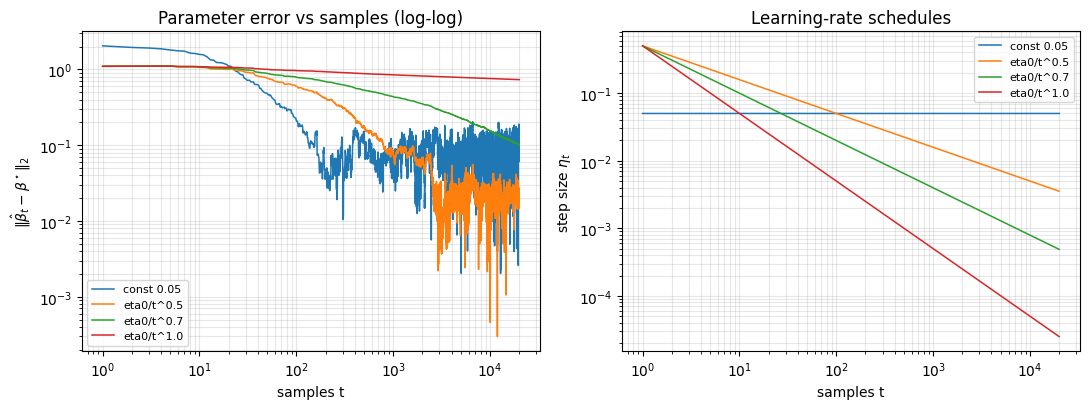

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))

colors = {'const 0.05':'#1f77b4', 'eta0/t^0.5':'#ff7f0e',
          'eta0/t^0.7':'#2ca02c', 'eta0/t^1.0':'#d62728'}
tt = np.arange(1, T + 1)
for name, (traj, err, etas) in results.items():
    ax[0].loglog(tt, err, color=colors[name], lw=1.1, label=name)
ax[0].set_xlabel('samples t'); ax[0].set_ylabel(r'$\|\hat\beta_t-\beta^\star\|_2$')
ax[0].set_title('Parameter error vs samples (log-log)')
ax[0].grid(True, which='both', alpha=0.3); ax[0].legend(fontsize=8)

for name, (traj, err, etas) in results.items():
    ax[1].loglog(tt, etas, color=colors[name], lw=1.1, label=name)
ax[1].set_xlabel('samples t'); ax[1].set_ylabel(r'step size $\eta_t$')
ax[1].set_title('Learning-rate schedules')
ax[1].grid(True, which='both', alpha=0.3); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 4. 결과 해석

측정된 tail 오차: 상수 0.05 → **0.111**, $\alpha{=}0.5$ → **0.022**, $\alpha{=}0.7$ → **0.100**, $\alpha{=}1.0$ → **0.732**.

1. **상수 학습률**(파랑)은 처음엔 빠르게 내려가지만 곧 **바닥에 붙어(plateau)** 더 내려가지 못한다(tail 0.111). $\sum\eta_t^2=\infty$(표에서 50)라 잡음이 소멸하지 않아 $\beta^\star$ 주변에서 분산 $\propto\eta$ 로 진동하기 때문이다.
2. **$\alpha=1.0$**(빨강)은 $\sum\eta_t^2<\infty$ 는 만족하지만 $\sum\eta_t$ 가 매우 천천히 발산해($\sum\eta_t\!\approx\!5.2$ 밖에 안 됨) 스텝이 초기에 급감 → 먼 출발점에서 **조기 둔화**, 이 지평선에서 가장 큰 오차(0.732)로 아직 수렴 못 함.
3. **$\alpha=0.5,\,0.7$**(주황·초록)은 Robbins-Monro 두 조건을 모두 만족($\tfrac12<\alpha\le1$)하면서 스텝을 오래 크게 유지해 로그-로그에서 깔끔한 직선 하강을 보인다. 유한지평선 $T{=}2\!\times\!10^4$ 에서는 스텝이 더 큰 $\alpha=0.5$ 가 가장 멀리 내려가(0.022) 최소였고, $\alpha=0.7$ 이 그 다음(0.100)이다. 단, $\alpha$ 가 작을수록 late-step 이 커 **점근적으로는 더 시끄럽다** — 지평선이 길어지면 순위가 바뀔 수 있다.

> **결론**: 상수 학습률은 수렴하지 못하고 $\eta$ 크기의 요동만 남기며, Robbins-Monro 를 만족하는 $\eta_t=\eta_0/t^\alpha\,(\tfrac12<\alpha\le1)$ 만이 참값으로 수렴한다. $\alpha$ 는 **초기 이동력↔점근 안정성**의 손잡이 — 유한지평선에선 작은 $\alpha$가, 장기적으론 $\alpha\to1$ 이 유리하다.

**다음 문제로**: Problem 2 는 1-샘플 대신 **미니배치**로 그래디언트를 평균해 잡음을 $\propto 1/B$ 로 줄이는 배치크기 상충을 본다.